In [ ]:
# YOLOv8 설치
!pip install ultralytics

# 필요한 라이브러리 임포트
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.5/974.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 32.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
# YOLOv8 모델 로드
print("YOLOv8 모델 로딩 중...")
model = YOLO('yolov8n.pt')  # 'n'은 nano 버전 (가장 가벼움), 's', 'm', 'l', 'x' 등 선택 가능

YOLOv8 모델 로딩 중...


In [ ]:
# 이미지 업로드 기능
print("이미지를 업로드하세요:")
uploaded = files.upload()

for filename in uploaded.keys():
    # 이미지 로드 및 객체 검출 실행
    print(f"{filename} 파일 분석 중...")
    results = model(filename)

이미지를 업로드하세요:


Saving 스크린샷 2025-04-11 093201.png to 스크린샷 2025-04-11 093201 (1).png
스크린샷 2025-04-11 093201 (1).png 파일 분석 중...

image 1/1 /content/스크린샷 2025-04-11 093201 (1).png: 448x640 3 dogs, 314.4ms
Speed: 15.0ms preprocess, 314.4ms inference, 31.2ms postprocess per image at shape (1, 3, 448, 640)


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

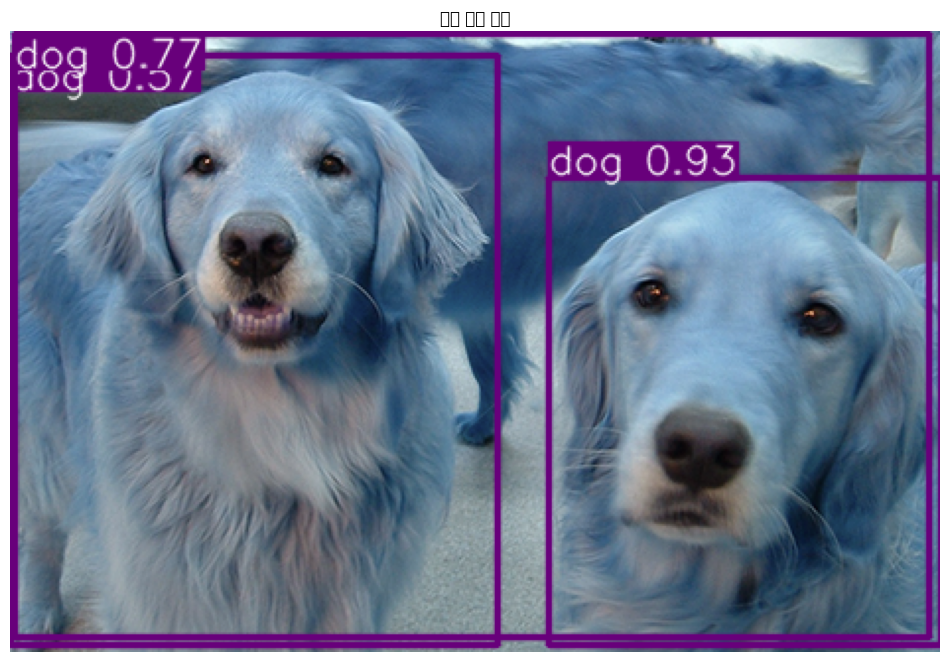

In [ ]:
 # 결과 이미지 시각화
res_plotted = results[0].plot()
plt.figure(figsize=(12, 10))
plt.imshow(res_plotted)
plt.axis('off')
plt.title('객체 검출 결과')
plt.show()

In [ ]:
# 검출된 객체 정보 출력
print("\n검출 결과:")
for r in results:
 for i, box in enumerate(r.boxes):
  class_id = int(box.cls[0])
class_name = model.names[class_id]
confidence = float(box.conf[0])
x1, y1, x2, y2 = box.xyxy[0].tolist()  # 박스 좌표

print(f"{i+1}. {class_name}: {confidence:.2f}, 위치: [{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}]")


검출 결과:
3. dog: 0.57, 위치: [0, 12, 247, 311]


In [ ]:
# 추가 옵션: 예제 이미지로 테스트하기
print("\n예제 이미지로 테스트하시겠습니까? (실행 시 예제 이미지에서 객체 검출)")
print("아래 셀을 실행하세요:")


예제 이미지로 테스트하시겠습니까? (실행 시 예제 이미지에서 객체 검출)
아래 셀을 실행하세요:


--2025-04-11 00:37:13--  https://ultralytics.com/images/bus.jpg
Resolving ultralytics.com (ultralytics.com)... 99.83.190.102, 75.2.70.75
Connecting to ultralytics.com (ultralytics.com)|99.83.190.102|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.ultralytics.com/images/bus.jpg [following]
--2025-04-11 00:37:14--  https://www.ultralytics.com/images/bus.jpg
Resolving www.ultralytics.com (www.ultralytics.com)... 172.64.147.154, 104.18.40.102, 2606:4700:4400::6812:2866, ...
Connecting to www.ultralytics.com (www.ultralytics.com)|172.64.147.154|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg [following]
--2025-04-11 00:37:14--  https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP re

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


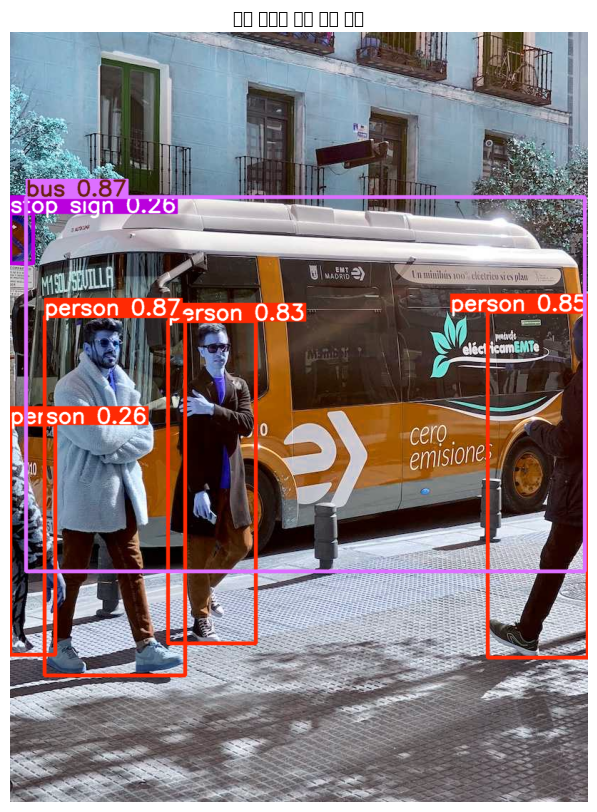


예제 이미지 검출 결과:
1. bus: 0.87
2. person: 0.87
3. person: 0.85
4. person: 0.83
5. person: 0.26
6. stop sign: 0.26


In [ ]:
# 예제 이미지 다운로드 및 테스트 (선택 사항)
!wget https://ultralytics.com/images/bus.jpg -O example.jpg

example_results = model('example.jpg')
example_plotted = example_results[0].plot()

plt.figure(figsize=(12, 10))
plt.imshow(example_plotted)
plt.axis('off')
plt.title('예제 이미지 객체 검출 결과')
plt.show()

print("\n예제 이미지 검출 결과:")
for r in example_results:
    for i, box in enumerate(r.boxes):
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])
        print(f"{i+1}. {class_name}: {confidence:.2f}")